In [112]:
from py_files.setup import *
setup_notebook()

import py_files.elas as elas
from matplotlib.lines   import Line2D
from matplotlib.patches import Patch
from scipy.interpolate  import interp1d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Effect of $\varepsilon^S$ and $\phi$ on `wages` and `welfare`

**Goal:** Describe effect of the `capital supply elasticity` and of the friction of moving between sectors, i.e.
\begin{align*}
    &\frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S), \quad \\
    &\frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad 
\end{align*}
To discuss the effect of the `capital supply elasticity` and relation to NCM, through *Chamley-Judd*.

**Output:**

1. Plot the wage/rent effects in $(w_I/r_K, \varepsilon^S)$.
2. Plot the wage/rent effects in $(w_I/r_K, \phi)$.
3. Do the simulation for some chosen elasticities.

*`1. prep`*

In [113]:
m = CapIncModel_single()
out = m.calibrate(target_elas=m.phi, verbose=False)

*`2. welfare incidence`*

In [114]:

# 1. set up
T=25; tau0=0.0; rho=0.85; tail=50; tau_ss=0.0 
ss0 = m.solve_steady_state(tau=tau0)

# 2. params and sim 
# 2.1 temp
# tauT = 0.0
# net_long, tau_long, dlog_net_long, tauT = shocks.temp_tc(
#     T=T, tail=tail,
# )
# sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
# fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
# )
# plt.close(fig)

# 2.2 perm
tauT = -0.1
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)
sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)
plt.close(fig)

# 3. compute welfare incidence
welf = elas.welfare_incidence(sim)

*print main calibration results*

*`3. elasticities`*

In [115]:
out_base = elas.dem_sup_elas(m, tau=0.0)
epsD_baseline = out_base['epsD']

print(f"Baseline epsD    = {epsD_baseline:.4f}")
print(f"Baseline epsS_LR = {out_base['epsS_LR']:.4f}")
print(f"Baseline epsS_SR = {out_base['epsS_SR']:.4f}")

epsS_grid = np.linspace(0.001, 20, 2000)

w_C_S, w_I_S, r_K_S = [], [], []
for epsS in epsS_grid:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=epsS)
    w_C_S.append(res['w_C_elas'])
    w_I_S.append(res['w_I_elas'])
    r_K_S.append(res['r_K_elas'])

w_C_S = np.array(w_C_S)
w_I_S = np.array(w_I_S)
r_K_S = np.array(r_K_S)

total_S    = w_C_S + w_I_S + r_K_S
share_wC_S = w_C_S / total_S * 100
share_wI_S = w_I_S / total_S * 100
share_rK_S = r_K_S / total_S * 100
epsS_base  = out_base['epsS_LR']

Baseline epsD    = 1.3757
Baseline epsS_LR = 1.6040
Baseline epsS_SR = 0.1288


In [116]:
# 1. model
res = elas.wr_tax_elas(m, elas_out=out_base)
print({k: round(v, 3) for k, v in res.items()})

# 2. NCM, set alpha_L=beta_L=2/3
res_ncm = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=10000000000)
print({k: round(v, 3) for k, v in res_ncm.items()})

{'w_C_elas': np.float64(0.35), 'w_I_elas': np.float64(0.861), 'r_K_elas': np.float64(0.554), 'w_I_breakdown': np.float64(0.308)}
{'w_C_elas': np.float64(0.65), 'w_I_elas': np.float64(0.571), 'r_K_elas': np.float64(0.0), 'w_I_breakdown': np.float64(0.571)}


*`4. $\phi$`*

In [117]:
# ── epsS sweep (marginal) ─────────────────────────────────────────────────────
# out_base  = elas.dem_sup_elas(m, tau=0.0)
# epsS_base = out_base['epsS_LR']
# epsS_grid = np.linspace(0.01, 20, 2000)

w_C_S, w_I_S, r_K_S = [], [], []
for epsS in epsS_grid:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=epsS)
    w_C_S.append(res['w_C_elas'])
    w_I_S.append(res['w_I_elas'])
    r_K_S.append(res['r_K_elas'])

w_C_S, w_I_S, r_K_S = np.array(w_C_S), np.array(w_I_S), np.array(r_K_S)
total_S    = w_C_S + w_I_S + r_K_S
share_wC_S = w_C_S / total_S * 100
share_wI_S = w_I_S / total_S * 100
share_rK_S = r_K_S / total_S * 100

# ── phi sweep — MARGINAL (price elasticity) ───────────────────────────────────
phi_grid = np.linspace(0.001, 20, 500)
phi_base = 0.3

w_C_Pm, w_I_Pm, r_K_Pm = [], [], []
for phi in phi_grid:
    m.phi = phi
    out = elas.dem_sup_elas(m, tau=0.0)
    res = elas.wr_tax_elas(m, elas_out=out, epsD=out['epsD'])
    w_C_Pm.append(res['w_C_elas'])
    w_I_Pm.append(res['w_I_elas'])
    r_K_Pm.append(res['r_K_elas'])

m.phi = 1.35

w_C_Pm, w_I_Pm, r_K_Pm = np.array(w_C_Pm), np.array(w_I_Pm), np.array(r_K_Pm)
total_Pm    = w_C_Pm + w_I_Pm + r_K_Pm
share_wC_Pm = w_C_Pm / total_Pm * 100
share_wI_Pm = w_I_Pm / total_Pm * 100
share_rK_Pm = r_K_Pm / total_Pm * 100

# ── phi sweep — WELFARE (full simulation) ────────────────────────────────────
phi_grid_welf = np.linspace(0.001, 3, 150)

w_C_Pw, w_I_Pw, r_K_Pw = [], [], []
for phi in phi_grid_welf:
    m.phi = phi
    sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
    _, _, _, sim = build_output_single.welfare_effects(
        m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
    )
    plt.close('all')
    welf  = elas.welfare_incidence(sim)
    total = welf['consump_w'] + welf['investm_w'] + welf['capital_o']
    w_C_Pw.append(welf['consump_w'] / total * 100)
    w_I_Pw.append(welf['investm_w'] / total * 100)
    r_K_Pw.append(welf['capital_o'] / total * 100)

m.phi = 1.35

w_C_Pw, w_I_Pw, r_K_Pw = np.array(w_C_Pw), np.array(w_I_Pw), np.array(r_K_Pw)
total_Pw    = w_C_Pw + w_I_Pw + r_K_Pw
share_wC_Pw = w_C_Pw / total_Pw * 100
share_wI_Pw = w_I_Pw / total_Pw * 100
share_rK_Pw = r_K_Pw / total_Pw * 100

*`5. plot`*

In [118]:
# Light versions of each color for phi sweep
def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

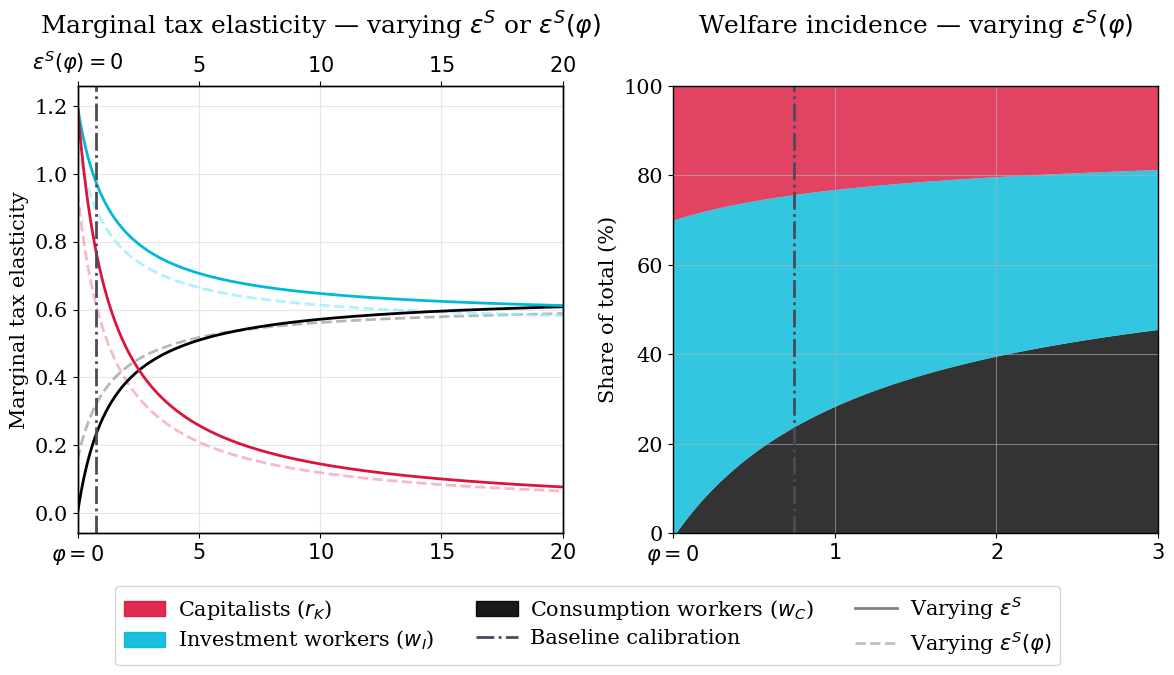

In [119]:
colors = ['crimson', 'k', '#00B8D9'] #4A4A5A
colors_light = [lighten_color(c, 0.4) for c in colors]

legend_handles = [
    Patch(color=colors[0], alpha=0.9, label=r'Capitalists ($r_K$)'),
    Patch(color=colors[2], alpha=0.9, label=r'Investment workers ($w_I$)'),
    Patch(color=colors[1], alpha=0.9, label=r'Consumption workers ($w_C$)'),
    Line2D([0], [0], color='#4A4A5A', lw=2, ls='-.', label=r'Baseline calibration'),
    Line2D([0], [0], color='gray', lw=2, ls='-',  label=r'Varying $\varepsilon^S$'),
    Line2D([0], [0], color='gray', lw=2, ls='--', alpha=0.5, label=r'Varying $\varepsilon^S(\varphi)$'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# ── Left: marginal incidence, both sweeps ─────────────────────────────────────
ax = axes[0]

phi_mapped = np.linspace(epsS_grid[0], epsS_grid[-1], len(phi_grid))
ax.plot(phi_mapped, w_C_Pm, color=colors_light[1], lw=2, ls='--', alpha=0.7)
ax.plot(phi_mapped, w_I_Pm, color=colors_light[2], lw=2, ls='--', alpha=0.7)
ax.plot(phi_mapped, r_K_Pm, color=colors_light[0], lw=2, ls='--', alpha=0.7)

ax.plot(epsS_grid, w_C_S, color=colors[1], lw=2, ls='-')
ax.plot(epsS_grid, w_I_S, color=colors[2], lw=2, ls='-')
ax.plot(epsS_grid, r_K_S, color=colors[0], lw=2, ls='-')
ax.axvline(0.75, color="#4A4A5A", lw=2, ls='-.')

ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xticklabels([r'$\varphi=0$', r'$5$', r'$10$', r'$15$', r'$20$'])
ax.set_ylabel('Marginal tax elasticity')
ax.set_title(r'Marginal tax elasticity — varying $\varepsilon^S$ or $\varepsilon^S(\varphi)$', pad=10)
ax.set_xlim(0, 20)
ax.grid(True, alpha=0.3)

ax2 = ax.twiny()
ax2.set_xlim(0, 20)
ax2.set_xticks([0, 5, 10, 15, 20])
ax2.set_xticklabels([r'$\varepsilon^S(\varphi)=0$', r'$5$', r'$10$', r'$15$', r'$20$'])

# ── Right: welfare incidence stackplot ────────────────────────────────────────
ax = axes[1]

ax.stackplot(phi_grid_welf, share_wC_Pw, share_wI_Pw, share_rK_Pw,
             colors=[colors[1], colors[2], colors[0]], alpha=0.8)
ax.axvline(0.75, color="#4A4A5A", lw=2, ls='-.')

ax.set_ylabel('Share of total (%)')
ax.set_title(r'Welfare incidence — varying $\varepsilon^S(\varphi)$', pad=37)
ax.set_xlim(0, 3)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.6)

ax.set_xticks([0, 1.0, 2.0, 3.0])
ax.set_xticklabels([r'$\varphi=0$', r'$1$', r'$2$', r'$3$'])

# ── Single merged legend centred below both panels ────────────────────────────
blank = Line2D([0], [0], color='none', label='')

fig.legend(handles=legend_handles,
           loc='lower center', bbox_to_anchor=(0.5, 0.02),
           frameon=True, ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.savefig('0_output/main_arg.png', dpi=200)
plt.show()

In [120]:
# # ── Figure 2: welfare incidence (single panel) ───────────────────────────────
# legend_handles = [
#     Patch(color=colors[0], alpha=0.8, label=r'Capitalists ($r_K$)'),
#     Patch(color=colors[2], alpha=0.8, label=r'Investment workers ($w_I$)'),
#     Patch(color=colors[1], alpha=0.8, label=r'Consumption workers ($w_C$)'),
#     Line2D([0], [0], color='#E8E8E8', ls='-' , lw=2, label='Fernández-Villaverde et al. (2024)'),
#     Line2D([0], [0], color='#E8E8E8', ls='-.', lw=2, label='Goolsbee (1998)'),
#     Line2D([0], [0], color='#E8E8E8', ls='--', lw=2, label='Ekerdt and Wu (2024)'),
#     Line2D([0], [0], color='#E8E8E8', ls=':' , lw=2, label='GG-B (2025)'),
    
#     Line2D([0], [0], color='#41FAB4', ls='-' , lw=2, label='GG-B (2025)'),
#     Line2D([0], [0], color='#41FAB4', ls='-.', lw=2, label='Hsieh et al. (2019)'),
# ]

# fig2, ax2 = plt.subplots(1, 1, figsize=(12, 5))

# ax2.stackplot(phi_grid_welf, share_wC_Pw, share_wI_Pw, share_rK_Pw,
#               colors=[colors[1], colors[2], colors[0]], alpha=0.8)

# ax2.axvline(0.05, color='#E8E8E8', ls='-' , lw=2)
# ax2.axvline(0.1 , color='#E8E8E8', ls='-.', lw=2)
# ax2.axvline(0.3 , color='#E8E8E8', ls='--', lw=2)
# ax2.axvline(0.4 , color='#E8E8E8', ls=':' , lw=2)

# ax2.axvline(1.0 , color='#41FAB4', ls='-' , lw=2)
# ax2.axvline(2.0 , color='#41FAB4', ls='-.', lw=2)

# ax2.set_xlabel(r'$\varphi$')
# ax2.set_ylabel('Share of total (%)')
# ax2.set_title(r'Welfare incidence — varying sectoral elasticity of substitution $(\varphi)$')
# ax2.set_xlim(0, 3)
# ax2.set_ylim(0, 100)
# ax2.grid(True, alpha=0.3)
# ax2.xaxis.set_major_locator(plt.MultipleLocator(0.5))

# fig2.legend(handles=legend_handles, loc='lower center', ncol=3,
#             bbox_to_anchor=(0.5, -0.2), frameon=True)
# plt.tight_layout()
# plt.show()

# # ── Spot checks ───────────────────────────────────────────────────────────────
# print("\n── epsS spot checks ──")
# for eps in [0.1, 1.0, epsS_base, 10, 25]:
#     res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=eps)
#     tot = sum(res.values())
#     print(f"epsS={eps:8.2f}  |  wC={res['w_C_elas']:6.3f}  wI={res['w_I_elas']:6.3f}  rK={res['r_K_elas']:6.3f}  |  shares: {res['w_C_elas']/tot*100:.0f}% / {res['w_I_elas']/tot*100:.0f}% / {res['r_K_elas']/tot*100:.0f}%")

# print("\n── phi spot checks ──")
# for phi in [0.1, 0.5, phi_base, 3.0, 10.0]:
#     m.phi = phi
#     out = elas.dem_sup_elas(m, tau=0.0)
#     res = elas.wr_tax_elas(m, elas_out=out)
#     tot = sum(res.values())
#     print(f"phi={phi:5.2f}  epsD={out['epsD']:6.3f}  epsS={out['epsS_LR']:6.3f}  |  wC={res['w_C_elas']:6.3f}  wI={res['w_I_elas']:6.3f}  rK={res['r_K_elas']:6.3f}  |  shares: {res['w_C_elas']/tot*100:.0f}% / {res['w_I_elas']/tot*100:.0f}% / {res['r_K_elas']/tot*100:.0f}%")

# m.phi = 1.35  # restore

*`assessing the effect on the labour share`*

In [121]:
# # ── factor share divergence sweep ─────────────────────────────────────────────
# # alpha_L = 0.5 - 0.5t,  beta_L = 0.5 + 0.5t,  t in [0, 1]
# # DK calib: alphaL=0.6107, betaL=0.6681
# # t* where alphaL = 0.6107 → 0.5 - 0.5t = 0.6107 → t = -0.2214  (outside [0,1])
# # t* where betaL  = 0.6681 → 0.5 + 0.5t = 0.6681 → t =  0.3362

# t_grid = np.linspace(0.001, 0.25, 500)

# # DK calib marker: use betaL to locate t* (alphaL=0.6107 is outside sweep range)
# t_star = (0.6681 - 0.5) / 0.5  # ≈ 0.3362

# w_C_t, w_I_t, r_K_t = [], [], []
# for t in t_grid:
#     m.alphaL = 0.5 - 0.5 * t
#     m.alphaK = 1 - m.alphaL
#     m.betaL  = 0.5 + 0.5 * t
#     m.betaK  = 1 - m.betaL

#     out = elas.dem_sup_elas(m, tau=0.0)
#     res = elas.wr_tax_elas(m, elas_out=out, epsD=out['epsD'])
#     w_C_t.append(res['w_C_elas'])
#     w_I_t.append(res['w_I_elas'])
#     r_K_t.append(res['r_K_elas'])

# # restore DK calibration
# m.alphaL = 0.6107
# m.alphaK = 1 - m.alphaL
# m.betaL  = 0.6681
# m.betaK  = 1 - m.betaL

# w_C_t = np.array(w_C_t)
# w_I_t = np.array(w_I_t)
# r_K_t = np.array(r_K_t)

# # ── plot ──────────────────────────────────────────────────────────────────────
# colors = ['crimson', 'k', '#00B8D9']

# legend_handles = [
#     Patch(color=colors[0], alpha=0.8, label=r'Capitalists ($r_K$)'),
#     Patch(color=colors[2], alpha=0.8, label=r'Investment workers ($w_I$)'),
#     Patch(color=colors[1], alpha=0.8, label=r'Consumption workers ($w_C$)'),
#     Line2D([0], [0], color='k', ls='--', lw=1, label=r'DK calib. ($\beta_L=0.668$)'),
# ]

# fig, ax = plt.subplots(figsize=(12, 5))

# ax.plot(t_grid, w_C_t, color=colors[1], lw=2, label=r'$w_C$')
# ax.plot(t_grid, w_I_t, color=colors[2], lw=2, label=r'$w_I$')
# ax.plot(t_grid, r_K_t, color=colors[0], lw=2, label=r'$r_K$')

# ax.axvline(0.6681 - 0.6107, color='k', ls='--', lw=1)

# ax.set_xlabel(r'$\alpha_L$ (consumption sector labour share)')
# ax.set_xticks([0.0, 0.05, 0.10, 0.15, 0.20, 0.25])
# ax.set_xticklabels([r'$\alpha_L=0.50$', r'$0.45$', r'$0.40$', r'$0.35$', r'$0.30$', r'$0.25$'])

# ax.set_ylabel('Tax elasticity')
# ax.set_title(r'Marginal tax incidence — varying factor intensity gap')
# ax.set_xlim(0, 0.25)

# # secondary x-axis showing betaL values
# ax2 = ax.twiny()
# ax2.set_xlim(0, 0.25)
# ax2.set_xticks([0.0, 0.05, 0.10, 0.15, 0.20, 0.25])
# ax2.set_xticklabels([r'$\beta_L=0.50$', r'$0.55$', r'$0.60$', r'$0.65$', r'$0.70$', r'$0.75$'])
# ax2.set_xlabel(r'$\beta_L$ (investment sector labour share)')

# ax.grid(True, alpha=0.3)
# fig.legend(handles=legend_handles, loc='lower center', ncol=2,
#            bbox_to_anchor=(0.5, -0.12), frameon=True)
# plt.tight_layout()
# plt.subplots_adjust(bottom=0.18)
# plt.show()